<a href="https://colab.research.google.com/github/Sara2004011/Progetto-Python-/blob/main/progetto.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

print('Librerie importate correttamente')

Librerie importate correttamente


In [10]:
DATASET_ID = "guriya79/mental-health-disorder"
FILE_NAME  = "mental_health_risk_dataset (1).csv"
OUTPUT_DIR = os.path.join(os.getcwd(), "data", "mental_health")

# 2. Download del dataset
kagglehub.dataset_download(DATASET_ID, output_dir=OUTPUT_DIR)

# 3. Caricamento del dataset in un DataFrame Pandas
# Usiamo os.path.join per unire il percorso della cartella e il nome del file
df = pd.read_csv(os.path.join(OUTPUT_DIR, FILE_NAME))

# 4. Verifica del caricamento
print(f'Dataset "Mental Health" caricato correttamente!')
print(f'Dimensioni: {df.shape[0]:,} righe × {df.shape[1]} colonne')

# Mostra le prime 5 righe per vedere i dati
df.head()

100%|██████████| 517k/517k [00:00<00:00, 87.0MB/s]

Extracting files...
Dataset "Mental Health" caricato correttamente!
Dimensioni: 25,000 righe × 25 colonne


,age,gender,marital_status,education_level,employment_status,sleep_hours,physical_activity_hours_per_week,screen_time_hours_per_day,social_support_score,work_stress_level,academic_pressure_level,job_satisfaction_score,financial_stress_level,working_hours_per_week,anxiety_score,depression_score,stress_level,mood_swings_frequency,concentration_difficulty_level,panic_attack_history,family_history_mental_illness,previous_mental_health_diagnosis,therapy_history,substance_use,mental_health_risk
0,56,Other,Single,Bachelor,Unemployed,8.600,2.800,9.600,7,10,3,7,8,40,5,4,8,8,3,1,0,1,1,1,1
1,47,Male,Single,Bachelor,Unemployed,4.500,2.700,3.000,10,6,9,1,10,31,3,7,4,9,3,0,0,0,0,0,0
2,56,Female,Divorced,Bachelor,Student,3.100,14.100,7.200,10,5,2,4,7,28,8,3,1,4,2,1,1,1,1,1,2
3,59,Other,Married,Bachelor,Employed,7.000,0.500,10.300,2,10,4,8,7,63,9,8,5,2,5,1,1,0,1,1,2
4,58,Male,Single,High School,Self-Employed,5.100,2.500,1.200,8,1,8,8,3,28,1,8,3,3,1,0,0,1,0,1,0


In [11]:
print("--- Informazioni Generali ---")
df.info()
print("--- Analisi Descrittive ---")
# Usiamo un gradiente che evidenzia i valori più alti (più scuri = valori più alti)
df.describe().T.style \
    .background_gradient(cmap='YlOrRd', subset=['mean', 'std']) \
    .format("{:.2f}") # Arrotonda a 2 decimali per pulizia

--- Informazioni Generali ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   age                               25000 non-null  int64  
 1   gender                            25000 non-null  object 
 2   marital_status                    25000 non-null  object 
 3   education_level                   25000 non-null  object 
 4   employment_status                 25000 non-null  object 
 5   sleep_hours                       25000 non-null  float64
 6   physical_activity_hours_per_week  25000 non-null  float64
 7   screen_time_hours_per_day         25000 non-null  float64
 8   social_support_score              25000 non-null  int64  
 9   work_stress_level                 25000 non-null  int64  
 10  academic_pressure_level           25000 non-null  int64  
 11  job_satisfaction_score            250

,count,mean,std,min,25%,50%,75%,max
age,25000.00,39.07,12.40,18.00,28.00,39.00,50.00,60.00
sleep_hours,25000.00,6.51,2.02,3.00,4.80,6.50,8.20,10.00
physical_activity_hours_per_week,25000.00,7.52,4.32,0.00,3.80,7.50,11.30,15.00
screen_time_hours_per_day,25000.00,6.47,3.17,1.00,3.70,6.50,9.20,12.00
social_support_score,25000.00,5.51,2.89,1.00,3.00,5.00,8.00,10.00
work_stress_level,25000.00,5.52,2.86,1.00,3.00,6.00,8.00,10.00
academic_pressure_level,25000.00,5.45,2.86,1.00,3.00,5.00,8.00,10.00
job_satisfaction_score,25000.00,5.47,2.87,1.00,3.00,5.00,8.00,10.00
financial_stress_level,25000.00,5.50,2.88,1.00,3.00,5.00,8.00,10.00
working_hours_per_week,25000.00,45.05,14.68,20.00,32.00,45.00,58.00,70.00


In [12]:
# 1. Calcoliamo i valori mancanti
missing = pd.DataFrame({
    'count': df.isnull().sum(),
    'percent': df.isnull().mean() * 100
})

# 2. Modifica qui: controlliamo se la SOMMA totale dei nulli è zero
if df.isnull().sum().sum() == 0:
    print(' Nessun valore mancante nel dataset!')
else:
    # Filtriamo per mostrare solo le colonne che hanno effettivamente dei mancanti
    missing_only = missing[missing['count'] > 0]
    print(f'Trovate {len(missing_only)} colonne con valori mancanti:')
    display(missing_only.style.bar(subset=['percent'], color='#d65f5f'))

 Nessun valore mancante nel dataset!


L'analisi della qualità dei dati mostra un dataset completo. Non essendo presenti valori nulli, non sarà necessaria alcuna operazione di imputazione nella fase di preprocessing

In [13]:
cat_cols = df.select_dtypes(include='object').columns.tolist()

print(f'Colonne categoriche ({len(cat_cols)}): {cat_cols}')

Colonne categoriche (4): ['gender', 'marital_status', 'education_level', 'employment_status']


In [14]:
num_cols = df.select_dtypes(include='number').columns.tolist()
print(f'Colonne numeriche ({len(num_cols)}): {num_cols}')

Colonne numeriche (21): ['age', 'sleep_hours', 'physical_activity_hours_per_week', 'screen_time_hours_per_day', 'social_support_score', 'work_stress_level', 'academic_pressure_level', 'job_satisfaction_score', 'financial_stress_level', 'working_hours_per_week', 'anxiety_score', 'depression_score', 'stress_level', 'mood_swings_frequency', 'concentration_difficulty_level', 'panic_attack_history', 'family_history_mental_illness', 'previous_mental_health_diagnosis', 'therapy_history', 'substance_use', 'mental_health_risk']


In [15]:
print(df['mental_health_risk'].value_counts())

mental_health_risk
1    11823
0     9357
2     3820
Name: count, dtype: int64


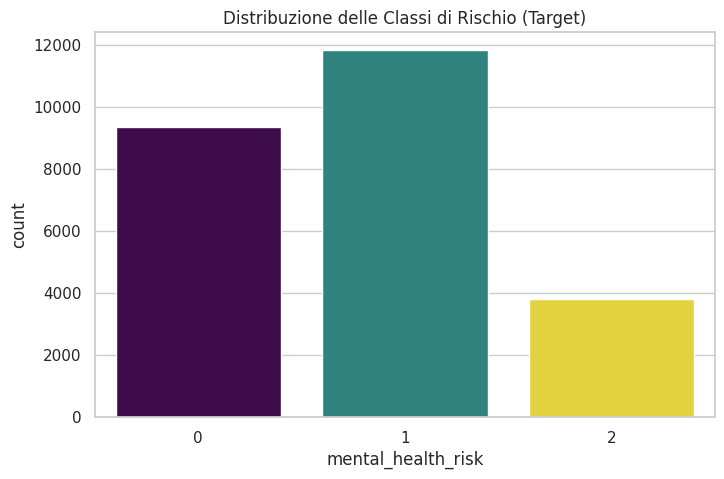

In [20]:
# GRAFICO 1: Distribuzione del Target
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='mental_health_risk', hue='mental_health_risk', palette='viridis', legend=False)
plt.title('Distribuzione delle Classi di Rischio (Target)')
plt.show()



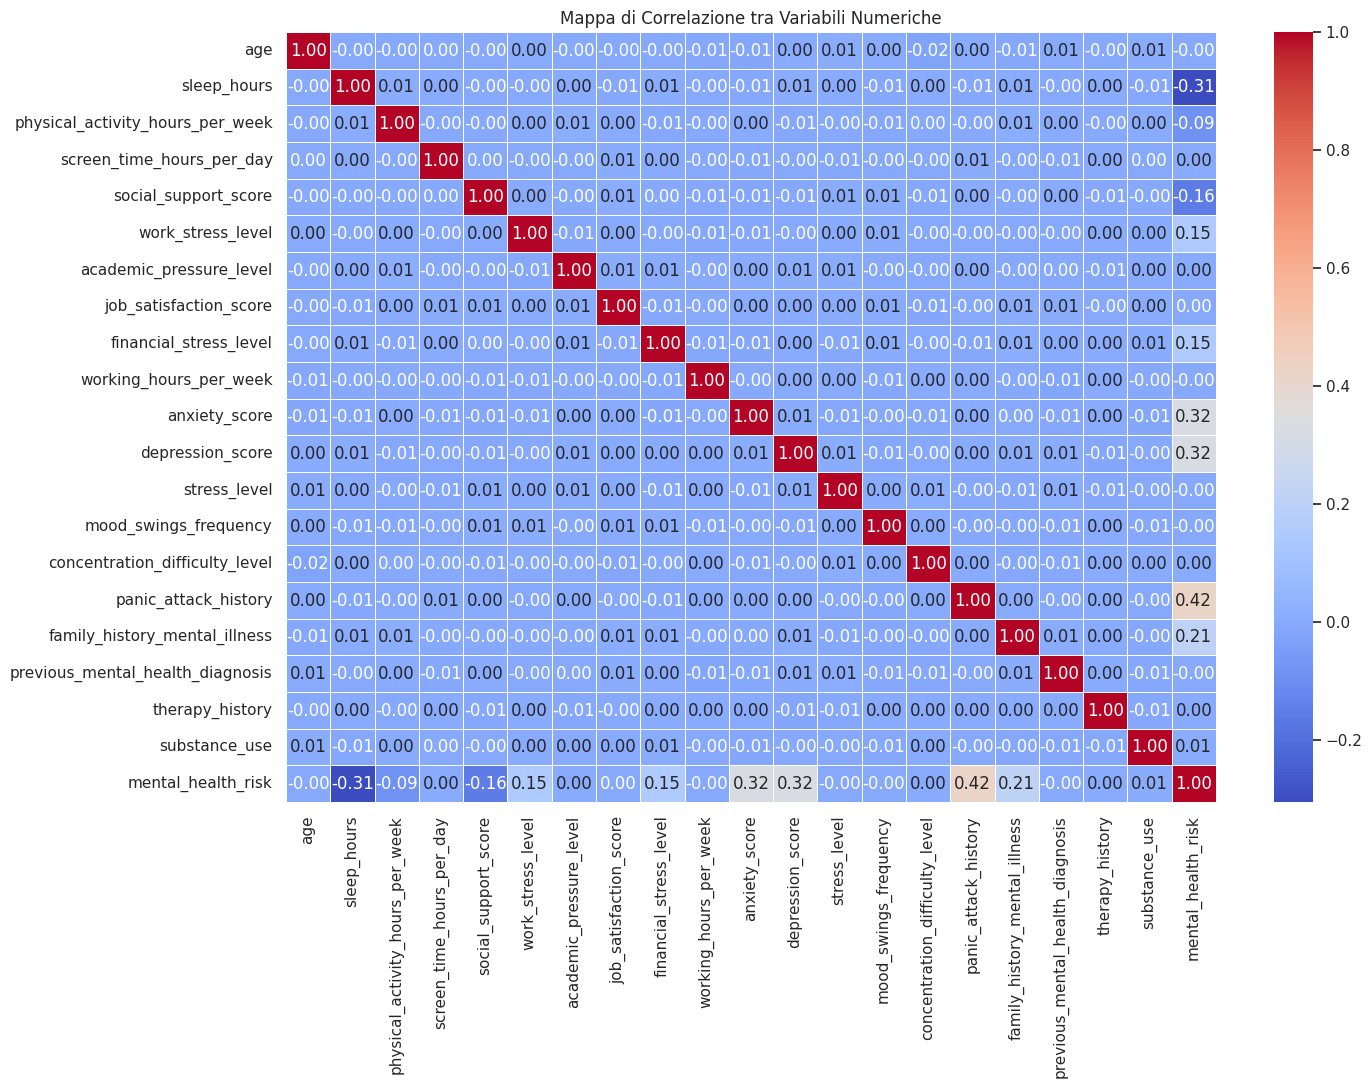

In [21]:

# GRAFICO 2: Matrice di Correlazione
plt.figure(figsize=(15, 10))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mappa di Correlazione tra Variabili Numeriche')
plt.show()


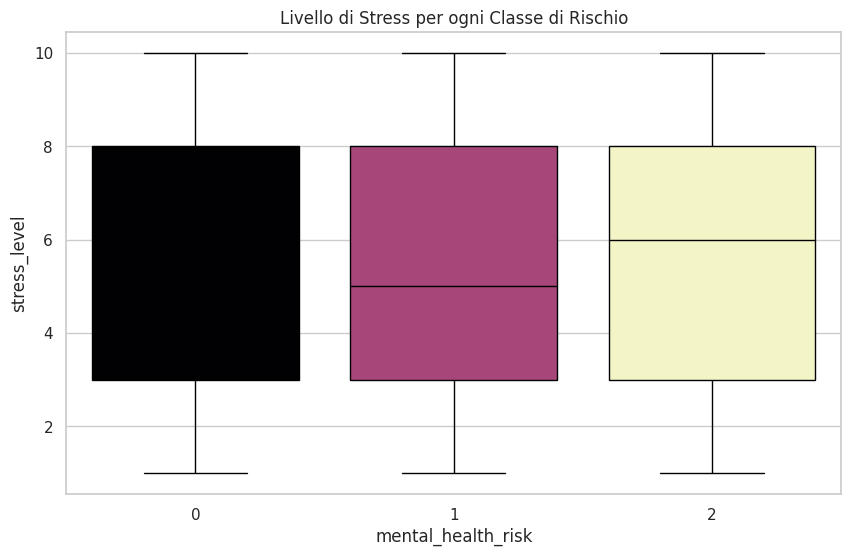

In [22]:
# GRAFICO 3: Relazione Stress e Rischio
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='mental_health_risk', y='stress_level', hue='mental_health_risk', palette='magma', legend=False)
plt.title('Livello di Stress per ogni Classe di Rischio')
plt.show()